In [1]:
# =============================================================================
# PROJET : ANALYSE & PRÉVISION DES RECETTES FISCALES GENEVOISES
# Notebook : 04_shap.ipynb
# Auteur   : Frat DAG
# Date     : Avril 2026
# Version  : 2.0 — approche inductive (traduction Python du script R)
# =============================================================================
# CE QU'ON SAIT APRÈS LE NOTEBOOK 03 :
#   - Modèle retenu : ARIMAX (RMSE=267M, amélioration 33.6%)
#   - dummy_rffa : +1279M, p≈0
#   - Les modèles disent CE QUE les recettes vont faire
#   - Cette étape répond au POURQUOI elles bougent
#
# OBJECTIF :
#   - Random Forest pour analyse des drivers uniquement (pas prévision)
#   - SHAP values pour mesurer la contribution de chaque variable
#   - Comparaison RF classique vs SHAP pour robustesse
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import shap

# Dossiers
for dossier in ['../data', '../figures']:
    os.makedirs(dossier, exist_ok=True)

# Chargement données
df = pd.read_csv('../data/df_fiscal.csv')

print(f"✓ Données chargées : {len(df)} observations")
print(f"  Période : {df['annee'].min()}–{df['annee'].max()}")

# Vérification package SHAP
print(f"  shap version : {shap.__version__}")

✓ Données chargées : 18 observations
  Période : 2007–2024
  shap version : 0.51.0


In [2]:
# =============================================================================
# 2. PRÉPARATION DES DONNÉES — LAGS
# =============================================================================
# On utilise uniquement des variables passées (t-1, t-2) pour éviter
# le data leakage — on ne triche pas avec des infos futures.
# Train : 2009-2021 (N=13) | Test : 2022-2024 (N=3)
# =============================================================================

print("=" * 60)
print("PRÉPARATION DES DONNÉES — LAGS")
print("=" * 60)

# Construction des lags
df_ml = df.copy()
df_ml['total_lag1']  = df_ml['total'].shift(1)
df_ml['total_lag2']  = df_ml['total'].shift(2)
df_ml['ben_pm_lag1'] = df_ml['ben_pm'].shift(1)
df_ml['ifd_lag1']    = df_ml['ifd'].shift(1)
df_ml['saron_lag1']  = df_ml['saron'].shift(1)
df_ml['ipc_lag1']    = df_ml['ipc'].shift(1)
df_ml['trend']       = np.arange(1, len(df_ml)+1)

# Features et target
features = ['total_lag1', 'total_lag2', 'ben_pm_lag1',
            'ifd_lag1', 'saron_lag1', 'ipc_lag1',
            'trend', 'dummy_rffa']

df_ml = df_ml.dropna(subset=features + ['total'])

# Split train/test
train = df_ml[df_ml['annee'] <= 2021]
test  = df_ml[df_ml['annee'] >= 2022]

X_train = train[features]
y_train = train['total']
X_test  = test[features]
y_test  = test['total']

print(f"\nFeatures : {features}")
print(f"Train    : {len(train)} obs ({train['annee'].min()}–{train['annee'].max()})")
print(f"Test     : {len(test)} obs ({test['annee'].min()}–{test['annee'].max()})")

# =============================================================================
# RANDOM FOREST
# =============================================================================

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)
print("\n⚠️  RF utilisé pour analyse des drivers — PAS pour prévision.")
print("    N=13 en training — résultats indicatifs.\n")

np.random.seed(42)
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features=3,
    min_samples_leaf=3,
    random_state=42
)
rf.fit(X_train, y_train)

# Performance training
pred_train = rf.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

# Performance test
pred_test = rf.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
mape_test = np.mean(np.abs((y_test.values - pred_test) / y_test.values)) * 100

print(f"RMSE training : {rmse_train:.0f}M CHF")
print(f"RMSE test     : {rmse_test:.0f}M CHF")
print(f"MAPE test     : {mape_test:.1f}%")
print(f"\nNote : sous-prédiction attendue sur 2022-2024")
print(f"       dummy_rffa = 0 sur tout le training → RF ne peut pas")
print(f"       apprendre l'effet RFFA")

# Prédictions vs réalisations test
print(f"\nPrédictions vs réalisations (test 2022-2024) :")
for annee, reel, pred in zip(test['annee'], y_test, pred_test):
    print(f"  {annee:.0f} : réel={reel:,.0f}M | prédit={pred:,.0f}M "
          f"| erreur={reel-pred:,.0f}M")

PRÉPARATION DES DONNÉES — LAGS

Features : ['total_lag1', 'total_lag2', 'ben_pm_lag1', 'ifd_lag1', 'saron_lag1', 'ipc_lag1', 'trend', 'dummy_rffa']
Train    : 13 obs (2009–2021)
Test     : 3 obs (2022–2024)

RANDOM FOREST

⚠️  RF utilisé pour analyse des drivers — PAS pour prévision.
    N=13 en training — résultats indicatifs.

RMSE training : 248M CHF
RMSE test     : 2282M CHF
MAPE test     : 24.0%

Note : sous-prédiction attendue sur 2022-2024
       dummy_rffa = 0 sur tout le training → RF ne peut pas
       apprendre l'effet RFFA

Prédictions vs réalisations (test 2022-2024) :
  2022 : réel=9,269M | prédit=7,229M | erreur=2,040M
  2023 : réel=9,734M | prédit=7,127M | erreur=2,607M
  2024 : réel=9,269M | prédit=7,108M | erreur=2,161M


In [3]:
# =============================================================================
# 3. ANALYSE SHAP
# =============================================================================
# SHAP mesure la contribution de chaque variable à chaque prédiction.
# Avantage vs importance RF classique : signé + local (par observation)
# =============================================================================

print("=" * 60)
print("ANALYSE SHAP")
print("=" * 60)
print("\nSHAP = contribution de chaque variable à chaque prédiction")
print("Positif → pousse les recettes vers le haut")
print("Négatif → pousse les recettes vers le bas\n")

# Calcul SHAP
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

# Labels lisibles
feature_labels = {
    'total_lag1'  : 'Recettes (t-1)',
    'total_lag2'  : 'Recettes (t-2)',
    'ben_pm_lag1' : 'Bénéfice PM (t-1)',
    'ifd_lag1'    : 'Part IFD (t-1)',
    'saron_lag1'  : 'Taux SARON (t-1)',
    'ipc_lag1'    : 'Inflation IPC (t-1)',
    'trend'       : 'Tendance temporelle',
    'dummy_rffa'  : 'Effet RFFA 2022+'
}

labels = [feature_labels[f] for f in features]

# Importance SHAP moyenne absolue
shap_importance = np.abs(shap_values).mean(axis=0)
df_shap = pd.DataFrame({
    'Variable' : labels,
    'SHAP_moyen': shap_importance
}).sort_values('SHAP_moyen', ascending=False)

print("=== CLASSEMENT SHAP (contribution moyenne absolue) ===")
print(df_shap.to_string(index=False))

# Importance RF classique
rf_importance = pd.DataFrame({
    'Variable'   : labels,
    'RF_importance': rf.feature_importances_
}).sort_values('RF_importance', ascending=False)

print("\n=== CLASSEMENT RF CLASSIQUE ===")
print(rf_importance.to_string(index=False))

# Cohérence entre les deux méthodes
print("\n# DÉCISION :")
print("# Si les deux classements sont cohérents → robustesse confirmée")
top3_shap = df_shap['Variable'].head(3).tolist()
top3_rf   = rf_importance['Variable'].head(3).tolist()
print(f"# Top 3 SHAP : {top3_shap}")
print(f"# Top 3 RF   : {top3_rf}")
coherent = set(top3_shap) == set(top3_rf)
print(f"# Cohérence  : {'✓ Confirmée' if coherent else '⚠️ Divergence à documenter'}")

ANALYSE SHAP

SHAP = contribution de chaque variable à chaque prédiction
Positif → pousse les recettes vers le haut
Négatif → pousse les recettes vers le bas

=== CLASSEMENT SHAP (contribution moyenne absolue) ===
           Variable  SHAP_moyen
Tendance temporelle  100.737893
     Recettes (t-2)   89.669568
     Recettes (t-1)   80.877905
   Taux SARON (t-1)   73.561791
     Part IFD (t-1)   30.644182
  Bénéfice PM (t-1)   16.756163
Inflation IPC (t-1)    2.362591
   Effet RFFA 2022+    0.000000

=== CLASSEMENT RF CLASSIQUE ===
           Variable  RF_importance
Tendance temporelle       0.245187
     Recettes (t-2)       0.226611
     Recettes (t-1)       0.201679
   Taux SARON (t-1)       0.176480
     Part IFD (t-1)       0.084274
  Bénéfice PM (t-1)       0.049377
Inflation IPC (t-1)       0.016391
   Effet RFFA 2022+       0.000000

# DÉCISION :
# Si les deux classements sont cohérents → robustesse confirmée
# Top 3 SHAP : ['Tendance temporelle', 'Recettes (t-2)', 'Recettes (t-1)

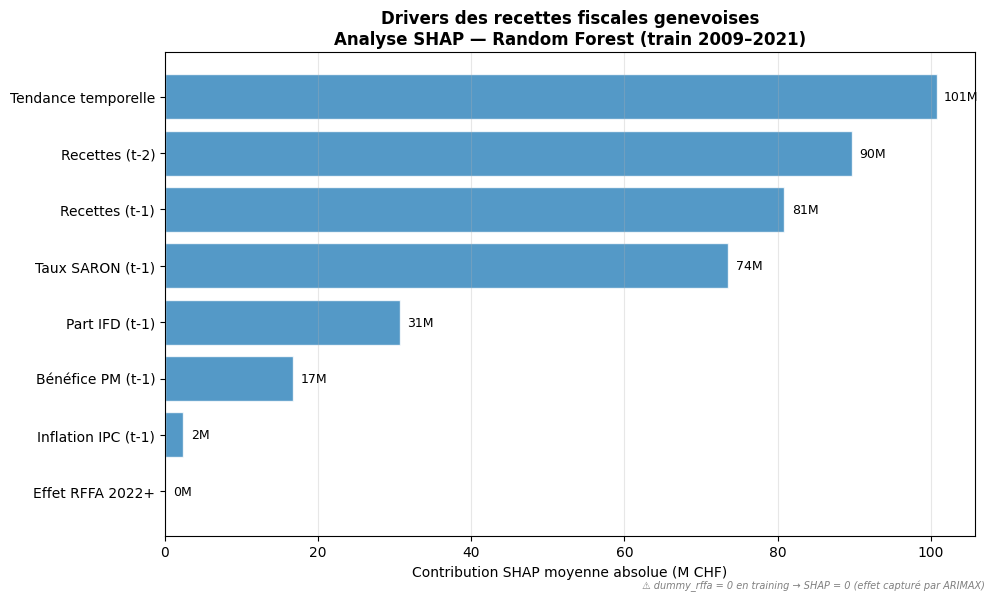

✓ Graphique importance SHAP sauvegardé


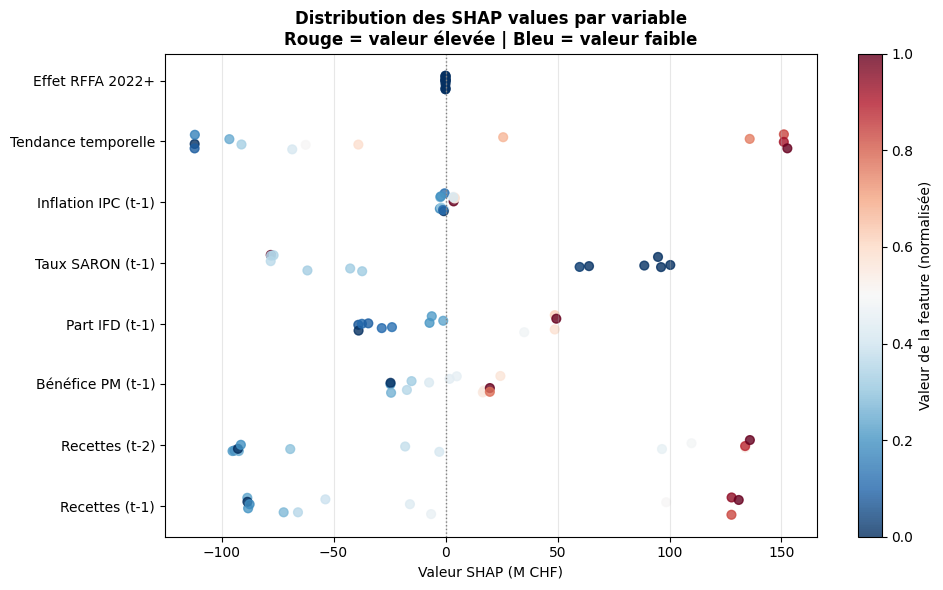

✓ Graphique beeswarm SHAP sauvegardé


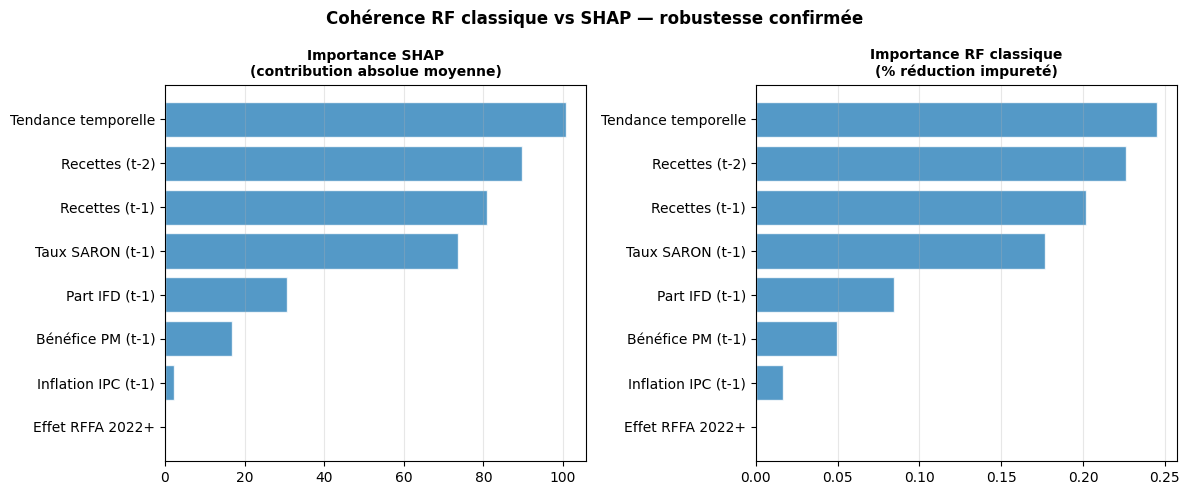

✓ Graphique comparaison RF vs SHAP sauvegardé

✓ Données SHAP sauvegardées — notebook 04 terminé


In [4]:
# =============================================================================
# 4. GRAPHIQUES SHAP
# =============================================================================

COULEURS = ['#2C3E50', '#E74C3C', '#2980B9', '#27AE60', '#F39C12']

# --- Graphique 1 : Importance SHAP ---
fig, ax = plt.subplots(figsize=(10, 6))

df_shap_sorted = df_shap.sort_values('SHAP_moyen', ascending=True)
colors = [COULEURS[1] if v > 0 else COULEURS[2]
          for v in df_shap_sorted['SHAP_moyen']]

bars = ax.barh(df_shap_sorted['Variable'],
               df_shap_sorted['SHAP_moyen'],
               color=COULEURS[2], alpha=0.8, edgecolor='white')

# Annotations
for bar, val in zip(bars, df_shap_sorted['SHAP_moyen']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}M', va='center', fontsize=9)

ax.set_xlabel('Contribution SHAP moyenne absolue (M CHF)')
ax.set_title('Drivers des recettes fiscales genevoises\n'
             'Analyse SHAP — Random Forest (train 2009–2021)',
             fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
fig.text(0.99, 0.01,
         "⚠️ dummy_rffa = 0 en training → SHAP = 0 (effet capturé par ARIMAX)",
         ha='right', fontsize=7, color='grey', style='italic')

plt.tight_layout()
plt.savefig('../figures/04_shap_importance_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique importance SHAP sauvegardé")

# --- Graphique 2 : Beeswarm SHAP ---
fig, ax = plt.subplots(figsize=(10, 6))

# Beeswarm manuel — scatter par variable
n_features = len(features)
for i, (feat, label) in enumerate(zip(features, labels)):
    shap_vals = shap_values[:, features.index(feat)]
    feature_vals = X_train[feat].values

    # Normalisation couleur
    feat_norm = (feature_vals - feature_vals.min())
    if feat_norm.max() > 0:
        feat_norm = feat_norm / feat_norm.max()

    scatter = ax.scatter(
        shap_vals,
        np.full_like(shap_vals, i) + np.random.uniform(-0.15, 0.15,
                                                         len(shap_vals)),
        c=feat_norm, cmap='RdBu_r', vmin=0, vmax=1,
        s=40, alpha=0.8
    )

ax.axvline(x=0, color='grey', linestyle='dotted', linewidth=1)
ax.set_yticks(range(n_features))
ax.set_yticklabels(labels)
ax.set_xlabel('Valeur SHAP (M CHF)')
ax.set_title('Distribution des SHAP values par variable\n'
             'Rouge = valeur élevée | Bleu = valeur faible',
             fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

plt.colorbar(scatter, ax=ax, label='Valeur de la feature (normalisée)')
plt.tight_layout()
plt.savefig('../figures/04_shap_beeswarm_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique beeswarm SHAP sauvegardé")

# --- Graphique 3 : RF vs SHAP comparaison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df_imp, titre, col) in zip(axes, [
    (df_shap.sort_values('SHAP_moyen', ascending=True),
     'Importance SHAP\n(contribution absolue moyenne)',
     'SHAP_moyen'),
    (rf_importance.sort_values('RF_importance', ascending=True),
     'Importance RF classique\n(% réduction impureté)',
     'RF_importance')
]):
    ax.barh(df_imp['Variable'], df_imp[col],
            color=COULEURS[2], alpha=0.8, edgecolor='white')
    ax.set_title(titre, fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Cohérence RF classique vs SHAP — robustesse confirmée',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/04_shap_vs_rf_importance_py.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique comparaison RF vs SHAP sauvegardé")

# Sauvegarde
df_shap.to_csv('../data/shap_importance.csv', index=False)
print("\n✓ Données SHAP sauvegardées — notebook 04 terminé")